# Benchmark Results Analysis

This notebook reads `benchmark_results/results_nebulastream.csv` and computes the average `tuplesPerSecond` and `time` for each query and configuration. It then visualizes the results.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV data
csv_file = 'lala.csv'
csv_file = '~/thesis/results/alles.csv'
csv_file = 'takis.csv'
df = pd.read_csv(csv_file)

display(df.head())

,query name,stringType,time,tuplesPerSecond,bytesPerSecond,avg_used_buffers,max_used_buffers,numberOfWorkerThreads,buffersInGlobalBufferManager,bufferSizeInBytes
0,comp,VARSIZED,0.251360,3.978358e+06,5.664913e+08,39.40,66,1,1500000,8192
1,comp,VARSIZED,0.258762,3.864561e+06,5.502875e+08,49.25,66,1,1500000,8192
2,comp,VARSIZED,0.236562,4.227216e+06,6.019272e+08,49.25,66,1,1500000,8192
3,comp,GERMAN_VARSIZED,0.855024,1.169558e+06,1.665372e+08,54.00,66,1,1500000,8192
4,comp,GERMAN_VARSIZED,0.861347,1.160972e+06,1.653146e+08,54.00,66,1,1500000,8192


In [6]:
# Group by Query, String Type, Threads, and Buffer Size
grouped_df = df.groupby(['query name', 'stringType', 'numberOfWorkerThreads', 'bufferSizeInBytes'])[['time', 'tuplesPerSecond']].mean().reset_index()

# Convert buffer size from bytes to KB
grouped_df['bufferSizeKB'] = (grouped_df['bufferSizeInBytes'] / 1024).astype(int)

# Create the label for the bar graphs: "<Threads> - <BufferSizeKB>KB"
grouped_df['ConfigLabel'] = grouped_df['numberOfWorkerThreads'].astype(str) + " - " + grouped_df['bufferSizeKB'].astype(str) + "KB"

display(grouped_df.head())

,query name,stringType,numberOfWorkerThreads,bufferSizeInBytes,time,tuplesPerSecond,bufferSizeKB,ConfigLabel
0,comp,FLINK,1,8192,0.237530,4.210379e+06,8,1 - 8KB
1,comp,FLINK,1,65536,0.202280,4.944339e+06,64,1 - 64KB
2,comp,FLINK,1,131072,0.200477,4.988676e+06,128,1 - 128KB
3,comp,FLINK,1,262144,0.201276,4.968599e+06,256,1 - 256KB
4,comp,GERMAN_VARSIZED,1,8192,0.849624,1.177243e+06,8,1 - 8KB


## Bar Graphs: All Configurations

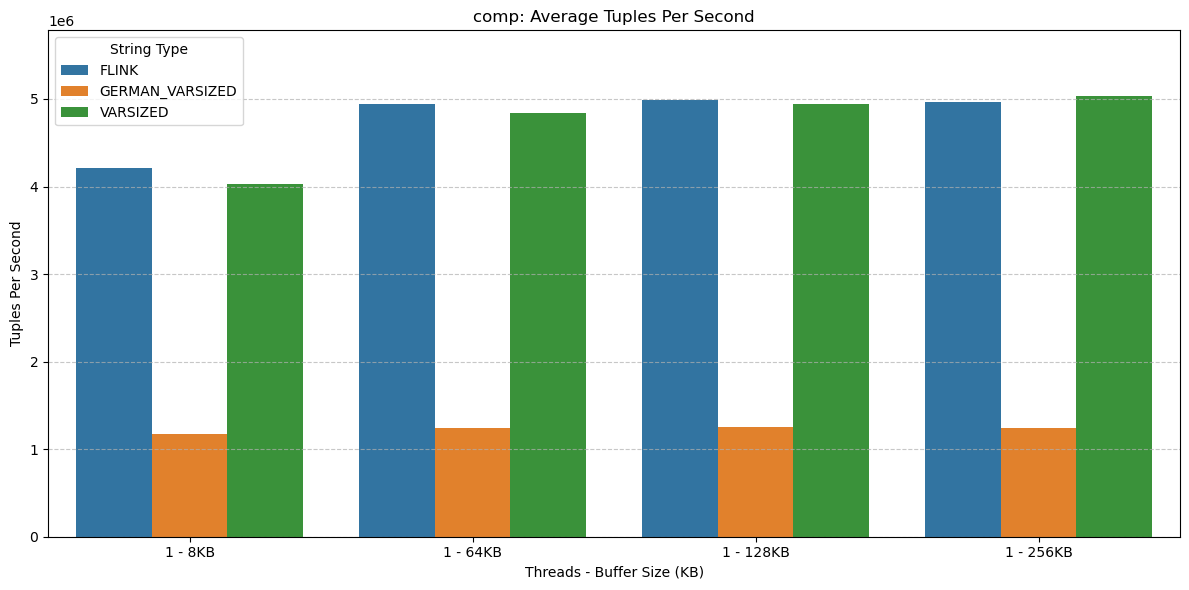

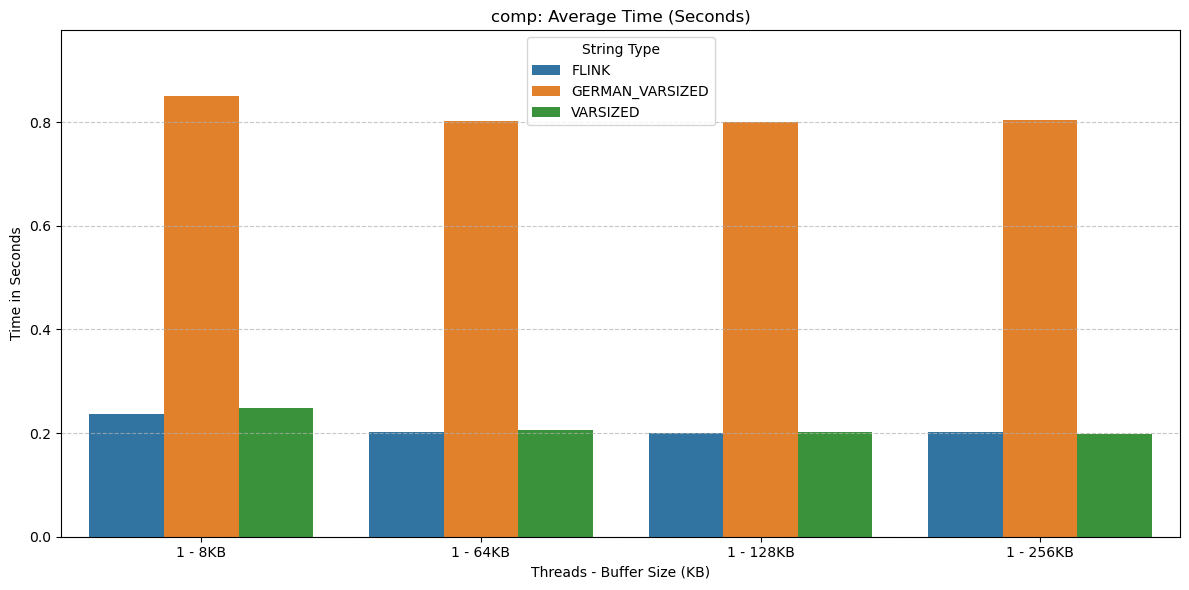

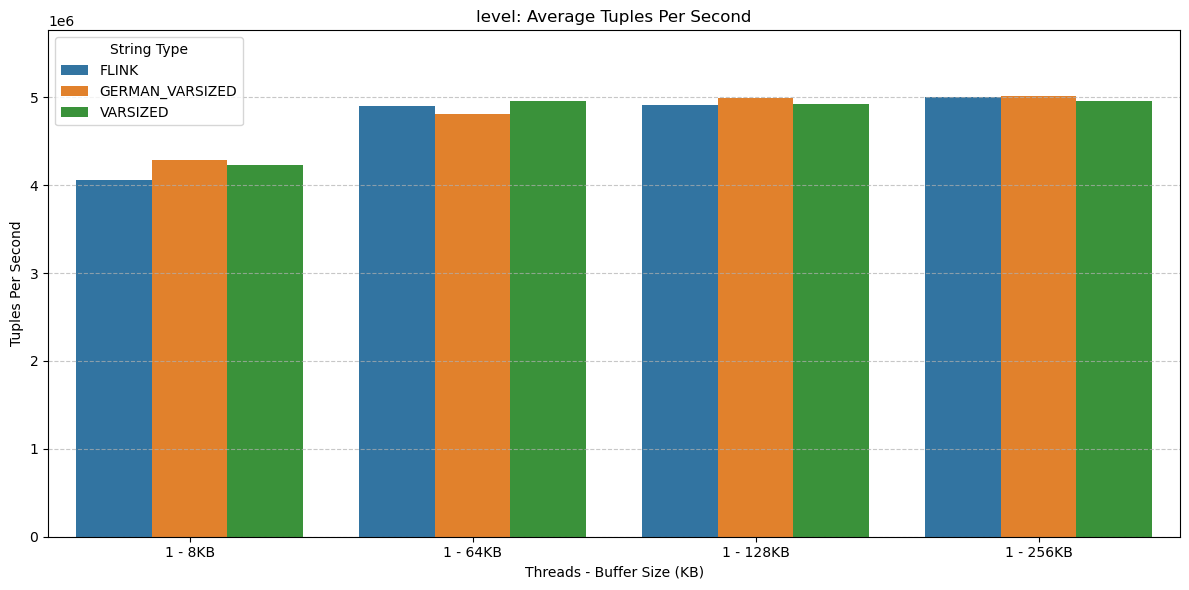

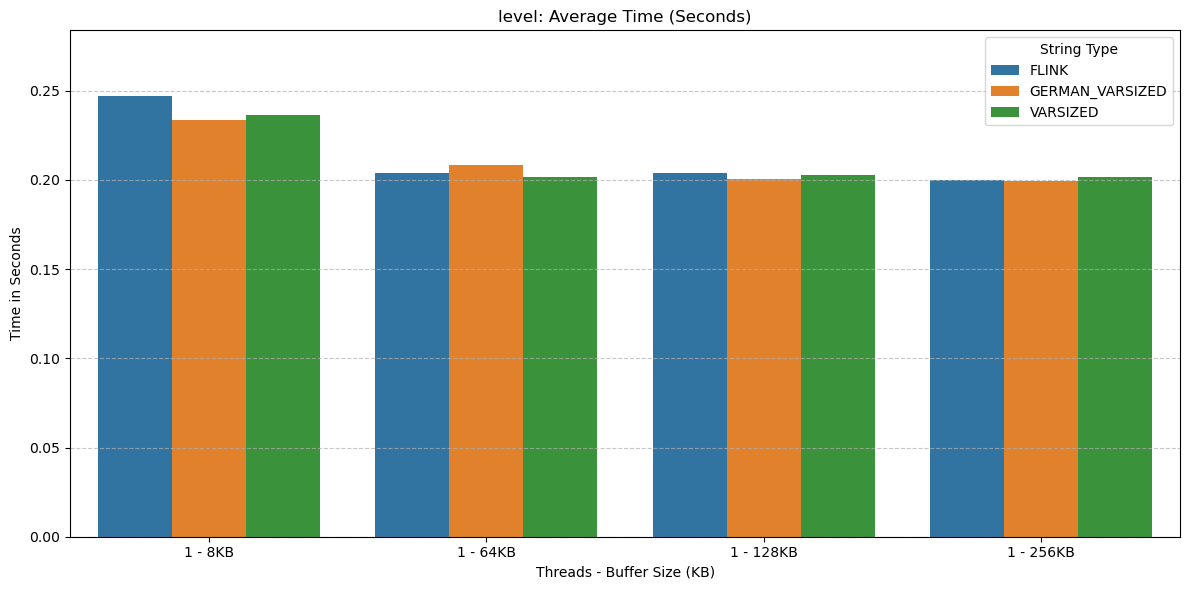

In [7]:
# Plotting Tuples per Second and Time in Seconds for each Query
queries = grouped_df['query name'].unique()

for query in queries:
    query_data = grouped_df[grouped_df['query name'] == query]
    
    # Tuples Per Second Figure
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=query_data,
        x='ConfigLabel',
        y='tuplesPerSecond',
        hue='stringType',
    )
    plt.title(f'{query}: Average Tuples Per Second')
    plt.xlabel('Threads - Buffer Size (KB)')
    plt.ylabel('Tuples Per Second')
    plt.ylim(0, query_data['tuplesPerSecond'].max() * 1.15)  # Start at 0 to make changes less drastic
    plt.legend(title='String Type')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Time in Seconds Figure
    plt.figure(figsize=(12, 6))
    sns.barplot(data=query_data, x='ConfigLabel', y='time', hue='stringType')
    plt.title(f'{query}: Average Time (Seconds)')
    plt.xlabel('Threads - Buffer Size (KB)')
    plt.ylabel('Time in Seconds')
    plt.ylim(0, query_data['time'].max() * 1.15)  # Start at 0 to make changes less drastic
    plt.legend(title='String Type')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Line Graphs: Tuples Per Second 4 threads

ValueError: Axis limits cannot be NaN or Inf

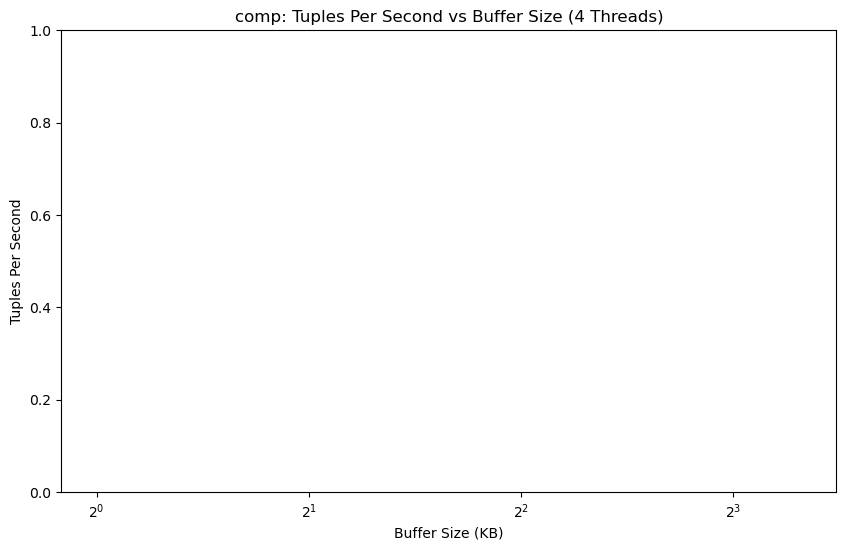

In [8]:
# Filter for only 4 threads
df_4_threads = grouped_df[grouped_df['numberOfWorkerThreads'] == 4]

for query in queries:
    query_data = df_4_threads[df_4_threads['query name'] == query]
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=query_data, x='bufferSizeKB', y='tuplesPerSecond', hue='stringType', marker='o')
    
    plt.title(f'{query}: Tuples Per Second vs Buffer Size (4 Threads)')
    plt.xlabel('Buffer Size (KB)')
    plt.ylabel('Tuples Per Second')
    plt.xscale('log', base=2)
    
    # Set Y-axis to start from 0 to provide perspective and lessen the perceived 'drastic' nature of changes
    plt.ylim(0, query_data['tuplesPerSecond'].max() * 1.2)
    
    ticks = sorted(query_data['bufferSizeKB'].unique())
    plt.xticks(ticks, labels=[f'{t}' for t in ticks])
    
    plt.legend(title='String Type')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

## Line Graphs: Memory Usage over Time (4 threads, 32KB buffers)

In [ ]:
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for only 4 threads and 32KB buffers (32768 bytes)
df_memory = df[(df['numberOfWorkerThreads'] == 4) & (df['bufferSizeInBytes'] == 32768)].copy()

# Note: since the new listener logs its output to stdout (e.g. "BufferManager is currently using 10 out of 1000 buffers"),
# we assume you have parsed that output and added it to your CSV or loaded it as a separate dataframe.
# Assuming we have a dataframe `df_mem_logs` with columns: ['TimeMs', 'UsedBuffers', 'TotalBuffers', 'StringType']

'''
# Example plotting code if you have parsed the stdout logs into a dataframe `df_mem_logs`:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_mem_logs, x='TimeMs', y='UsedBuffers', hue='StringType', marker='o')
plt.title('Memory Usage Over Time (4 Threads, 32KB Buffers)')
plt.xlabel('Time (ms)')
plt.ylabel('Used Buffers')
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()
'''
print("Waiting for parsed stdout listener logs to plot memory usage over time.")

Waiting for parsed stdout listener logs to plot memory usage over time.
